# Polity Classification using Cliopatria

Use the [Cliopatria dataset](https://www.nature.com/articles/s41597-025-04516-9) — a GeoJSON of ~15K polygon
records covering ~1,600 polities from 3400 BCE to 2024 CE — to assign polities to randomly
sampled people via point-in-polygon lookup.

**Approach:**
1. Load 1M sample of randomly sampled people (same as `sampling_classification.ipynb`)
2. Load Cliopatria GeoJSON as a GeoDataFrame
3. For each Holocene person with birth_year ≥ -3400, find Cliopatria polygons where:
   - `FromYear <= birth_year <= ToYear`
   - The polygon contains the person's (lon, lat) point
4. Analyze coverage, top polities, and compare with the deterministic + LLM approach

In [1]:
import sys, os
sys.path.insert(0, '..')
os.chdir('..')

from person import sample_person

os.chdir('BiggestPolities')

import numpy as np
import dill
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import Counter

## 1. Load sample

In [2]:
N = 10**6
PICKLE_FILE = f'../famous_person_sample_{N}.pkl'

if os.path.exists(PICKLE_FILE):
    print(f'Loading {N:,} people from {PICKLE_FILE}...')
    with open(PICKLE_FILE, 'rb') as f:
        people = dill.load(f)
else:
    print(f'Sampling {N:,} people...')
    people = [sample_person(light=True) for _ in tqdm(range(N), desc='Sampling')]
    with open(PICKLE_FILE, 'wb') as f:
        dill.dump(people, f)
    print(f'Saved to {PICKLE_FILE}')

print(f'Loaded {len(people):,} people')

Loading 1,000,000 people from ../famous_person_sample_1000000.pkl...
Loaded 1,000,000 people


## 2. Load Cliopatria

In [3]:
GEOJSON_PATH = 'cliopatria_polities_only.geojson'

print('Loading Cliopatria GeoJSON...')
clio_raw = gpd.read_file(GEOJSON_PATH)
print(f'Loaded {len(clio_raw):,} features')

# Filter out parenthesized names — these are "container" polities (e.g., "(Roman Empire)")
# that duplicate the territory of their component polities. Keeping them would double-count.
n_paren = clio_raw['Name'].str.startswith('(').sum()
clio = clio_raw[~clio_raw['Name'].str.startswith('(')].copy()
print(f'Removed {n_paren} container polities (parenthesized names)')
print(f'Remaining: {len(clio):,} features, {clio["Name"].nunique()} unique polity names')
print(f'Year range: {clio["FromYear"].min()} to {clio["ToYear"].max()}')
clio.head()

Loading Cliopatria GeoJSON...
Loaded 15,690 features
Removed 2703 container polities (parenthesized names)
Remaining: 12,987 features, 1522 unique polity names
Year range: -3400 to 2024


,Name,FromYear,ToYear,Area,Type,Wikipedia,SeshatID,MemberOf,Components,geometry
0,Sumerian City-States,-3400,-3201,22012.292763,POLITY,History of Sumer,,,,"POLYGON ((46.1356 31.59326, 46.07522 31.7218, ..."
1,Sumerian City-States,-3200,-3001,35614.595272,POLITY,History of Sumer,,,,"POLYGON ((46.05515 32.1717, 45.81501 32.68591,..."
2,Elam,-3200,-2701,4927.847813,POLITY,Elam,,,,"POLYGON ((48.05785 32.30024, 47.98145 32.30024..."
3,Sumerian City-States,-3000,-2701,45289.548838,POLITY,History of Sumer,,,,"POLYGON ((46.54074 31.78607, 46.63324 31.91461..."
4,Early Dynastic Period of Egypt,-3000,-2701,93286.062924,POLITY,Early Dynastic Period (Egypt),eg_dynasty_1,,,"POLYGON ((31.10071 31.6014, 30.97785 31.58354,..."


## 3. Build people GeoDataFrame

Filter to Holocene people with birth_year ≥ -3400 (Cliopatria's start date) and
create Point geometries from their (lon, lat) coordinates.

In [4]:
# HYDE grid → lat/lon conversion (from location.py)
HYDE_RES = 0.0833  # 360/4320 degrees

def row_col_to_latlon(row, col):
    lon = round(-180 + (col + 0.5) * HYDE_RES, 2)
    lat = round(90 - (row + 0.5) * HYDE_RES, 2)
    return lat, lon

records = []
for i, p in enumerate(people):
    if p.era == 'Paleolithic':
        continue
    if p.birth_year < -3400:
        continue
    loc = p.location
    lat, lon = row_col_to_latlon(p.row, p.col)
    records.append({
        'idx': i,
        'birth_year': p.birth_year,
        'country': loc.country,
        'lat': lat,
        'lon': lon,
    })

people_df = pd.DataFrame(records)
people_gdf = gpd.GeoDataFrame(
    people_df,
    geometry=gpd.points_from_xy(people_df['lon'], people_df['lat']),
    crs='EPSG:4326',
)

n_total = len(people)
n_paleo = sum(1 for p in people if p.era == 'Paleolithic')
n_pre_clio = sum(1 for p in people if p.era == 'Holocene' and p.birth_year < -3400)
n_eligible = len(people_gdf)

print(f'Total people:          {n_total:>10,}')
print(f'Paleolithic:           {n_paleo:>10,} (excluded — no coordinates)')
print(f'Holocene pre-3400 BCE: {n_pre_clio:>10,} (excluded — before Cliopatria coverage)')
print(f'Eligible for lookup:   {n_eligible:>10,} ({100*n_eligible/n_total:.1f}%)')

Total people:           1,000,000
Paleolithic:               44,434 (excluded — no coordinates)
Holocene pre-3400 BCE:     50,532 (excluded — before Cliopatria coverage)
Eligible for lookup:      905,034 (90.5%)


## 4. Spatial + temporal join

Strategy: process in century-sized batches. For each century:
1. Filter people born in that century
2. Filter Cliopatria features whose [FromYear, ToYear] overlaps that century
3. Spatial join (point-in-polygon)
4. Post-filter to exact year match

This keeps the spatial join size manageable.

In [5]:
# Assign century buckets
people_gdf['century'] = (people_gdf['birth_year'] // 100) * 100
clio_min_year = int(clio['FromYear'].min())
clio_max_year = int(clio['ToYear'].max())

centuries = sorted(people_gdf['century'].unique())
print(f'{len(centuries)} centuries to process, from {centuries[0]} to {centuries[-1]}')

all_matches = []

for cent in tqdm(centuries, desc='Processing centuries'):
    cent_end = cent + 99
    
    # People born in this century
    p_mask = people_gdf['century'] == cent
    p_cent = people_gdf[p_mask]
    if len(p_cent) == 0:
        continue
    
    # Cliopatria features overlapping this century
    c_mask = (clio['FromYear'] <= cent_end) & (clio['ToYear'] >= cent)
    c_cent = clio[c_mask]
    if len(c_cent) == 0:
        continue
    
    # Spatial join
    joined = gpd.sjoin(p_cent, c_cent, how='inner', predicate='within')
    if len(joined) == 0:
        continue
    
    # Post-filter: exact year match
    year_mask = (joined['FromYear'] <= joined['birth_year']) & (joined['birth_year'] <= joined['ToYear'])
    matched = joined[year_mask][['idx', 'birth_year', 'country', 'lat', 'lon', 'Name', 'FromYear', 'ToYear', 'Area']].copy()
    all_matches.append(matched)

matches_df = pd.concat(all_matches, ignore_index=True) if all_matches else pd.DataFrame()
print(f'\nTotal matches (person-polity pairs): {len(matches_df):,}')
print(f'Unique people matched: {matches_df["idx"].nunique():,} / {n_eligible:,} eligible')

55 centuries to process, from -3400 to 2000


Processing centuries: 100%|█████████████████████| 55/55 [00:19<00:00,  2.80it/s]


Total matches (person-polity pairs): 591,866
Unique people matched: 590,863 / 905,034 eligible


## 5. Resolve multiple matches

A person may fall inside multiple overlapping polities (e.g., a vassal state inside an empire).
Take the **smallest area** polygon as the most specific assignment.

In [6]:
BUFFER_DEG = 0.1  # degrees — see error budget above

# Identify people not matched by strict join
strict_matched_idx = set(pd.concat(all_matches)['idx']) if all_matches else set()
unmatched_mask = ~people_gdf['idx'].isin(strict_matched_idx)
unmatched_gdf = people_gdf[unmatched_mask].copy()
print(f'Unmatched after strict join: {len(unmatched_gdf):,}')

# Buffer Cliopatria polygons
print(f'Buffering {len(clio):,} Cliopatria polygons by {BUFFER_DEG}°...')
clio_buffered = clio.copy()
clio_buffered['geometry'] = clio_buffered.geometry.buffer(BUFFER_DEG)

# Repeat the century-batched spatial join for unmatched people only
buffer_matches = []
for cent in tqdm(sorted(unmatched_gdf['century'].unique()), desc='Buffer matching'):
    cent_end = cent + 99
    p_cent = unmatched_gdf[unmatched_gdf['century'] == cent]
    if len(p_cent) == 0:
        continue
    c_mask = (clio_buffered['FromYear'] <= cent_end) & (clio_buffered['ToYear'] >= cent)
    c_cent = clio_buffered[c_mask]
    if len(c_cent) == 0:
        continue
    joined = gpd.sjoin(p_cent, c_cent, how='inner', predicate='within')
    if len(joined) == 0:
        continue
    year_mask = (joined['FromYear'] <= joined['birth_year']) & (joined['birth_year'] <= joined['ToYear'])
    matched = joined[year_mask][['idx', 'birth_year', 'country', 'lat', 'lon', 'Name', 'FromYear', 'ToYear', 'Area']].copy()
    buffer_matches.append(matched)

buffer_df = pd.concat(buffer_matches, ignore_index=True) if buffer_matches else pd.DataFrame()
n_buffer_people = buffer_df['idx'].nunique() if len(buffer_df) > 0 else 0
print(f'\nBuffer recovered {n_buffer_people:,} additional people ({100*n_buffer_people/len(unmatched_gdf):.1f}% of previously unmatched)')

# Merge strict + buffer matches
all_matches_combined = all_matches + buffer_matches
matches_df = pd.concat(all_matches_combined, ignore_index=True) if all_matches_combined else pd.DataFrame()
print(f'\nCombined matches (person-polity pairs): {len(matches_df):,}')
print(f'Unique people matched: {matches_df["idx"].nunique():,} / {n_eligible:,} eligible')

Unmatched after strict join: 314,171
Buffering 12,987 Cliopatria polygons by 0.1°...


Buffer matching: 100%|██████████████████████████| 55/55 [00:01<00:00, 34.76it/s]


Buffer recovered 17,964 additional people (5.7% of previously unmatched)

Combined matches (person-polity pairs): 610,320
Unique people matched: 608,827 / 905,034 eligible


In [7]:
# For people with multiple matches, keep the smallest-area polity
if len(matches_df) > 0:
    best = matches_df.sort_values('Area').drop_duplicates(subset='idx', keep='first')
else:
    best = matches_df

n_matched = len(best)
n_multi = (matches_df.groupby('idx').size() > 1).sum()

print(f'People with exactly 1 match:  {n_matched - n_multi:>10,}')
print(f'People with multiple matches: {n_multi:>10,} (resolved by smallest area)')
print(f'People with no match:         {n_eligible - n_matched:>10,}')
print(f'\nCoverage: {n_matched:,} / {n_eligible:,} eligible ({100*n_matched/n_eligible:.1f}%)')
print(f'Coverage: {n_matched:,} / {n_total:,} total ({100*n_matched/n_total:.1f}%)')

People with exactly 1 match:     607,358
People with multiple matches:      1,469 (resolved by smallest area)
People with no match:            296,207

Coverage: 608,827 / 905,034 eligible (67.3%)
Coverage: 608,827 / 1,000,000 total (60.9%)


## 6. Top polities by sampled births (Cliopatria)

In [8]:
polity_counts = best['Name'].value_counts()

# Get year ranges from Cliopatria for each polity
polity_years = clio.groupby('Name').agg(start=('FromYear', 'min'), end=('ToYear', 'max'))

def fmt_year(y):
    if y < 0:
        return f'{-y} BCE'
    else:
        return f'{y} CE'

print(f'{"Rank":<5} {"Polity":<55} {"Years":<25} {"Count":>7} {"% of all":>14}')
print('-' * 110)
for i, (polity, count) in enumerate(polity_counts.head(50).items(), 1):
    p = count / n_total
    se = np.sqrt(p * (1 - p) / n_total) * 100
    yrs = polity_years.loc[polity]
    yr_str = f'{fmt_year(yrs["start"])}–{fmt_year(yrs["end"])}'
    print(f'{i:<5} {polity:<55} {yr_str:<25} {count:>7,} {100*p:>6.3f} ± {se:.3f}%')

print(f'\n... {len(polity_counts)} total polities assigned')

Rank  Polity                                                  Years                       Count       % of all
--------------------------------------------------------------------------------------------------------------
1     Qing Dynasty                                            1645 CE–1911 CE            37,491  3.749 ± 0.019%
2     Republic of India                                       1947 CE–2024 CE            28,655  2.865 ± 0.017%
3     People's Republic of China                              1950 CE–2024 CE            24,812  2.481 ± 0.016%
4     British Raj                                             1859 CE–1947 CE            19,581  1.958 ± 0.014%
5     Mughal Empire                                           1497 CE–1858 CE            14,459  1.446 ± 0.012%
6     Ming Dynasty                                            1375 CE–1644 CE            13,595  1.359 ± 0.012%
7     Roman Empire                                            31 BCE–394 CE              10,919  1.092 ± 0

## 7. Analyze unmatched people

Where are the gaps? Which countries/centuries have the most people not covered by Cliopatria?

In [9]:
matched_idx = set(best['idx'])
unmatched = people_gdf[~people_gdf['idx'].isin(matched_idx)].copy()

print(f'Unmatched: {len(unmatched):,} people\n')

# By country
by_country = unmatched['country'].value_counts()
print(f'{"Country":<30} {"Unmatched":>10} {"% of all":>8}')
print('-' * 50)
for country, count in by_country.head(20).items():
    print(f'{country:<30} {count:>10,} {100*count/n_total:>7.2f}%')

print(f'\nTop 20 countries account for {100*by_country.head(20).sum()/n_total:.1f}% of all people')

# Sample examples from top unmatched countries
print(f'\n\n{"="*80}')
print('Sample unmatched people (5 per top-10 country):')
print(f'{"="*80}')
for country in by_country.head(10).index:
    subset = unmatched[unmatched['country'] == country].sample(n=min(5, len(unmatched[unmatched['country'] == country])), random_state=42)
    print(f'\n--- {country} ({by_country[country]:,} unmatched) ---')
    for _, row in subset.iterrows():
        yr = row['birth_year']
        yr_str = f'{abs(yr)} BCE' if yr < 0 else f'{yr} CE'
        print(f'  {yr_str:>10}  ({row["lat"]:.2f}, {row["lon"]:.2f})')

Unmatched: 296,207 people

Country                         Unmatched % of all
--------------------------------------------------
India                              84,133    8.41%
China                              28,573    2.86%
Mexico                             24,465    2.45%
Brazil                             19,075    1.91%
Nigeria                             8,513    0.85%
Peru                                5,376    0.54%
Bangladesh                          5,349    0.53%
Sudan                               4,829    0.48%
Turkey                              4,824    0.48%
Indonesia                           4,375    0.44%
Colombia                            4,254    0.43%
Russia                              4,191    0.42%
Democratic Republic of Congo        4,136    0.41%
Pakistan                            4,031    0.40%
France                              3,158    0.32%
Iran                                3,125    0.31%
Algeria                             2,900    0.29%
Spai

In [10]:
# Unmatched by century (top gaps)
unmatched['century'] = (unmatched['birth_year'] // 100) * 100
by_century = unmatched.groupby('century').size().sort_values(ascending=False)

print(f'{"Century":<15} {"Unmatched":>10} {"% of all":>8}')
print('-' * 35)
for cent, count in by_century.head(15).items():
    label = f'{abs(cent)} BCE' if cent < 0 else f'{cent} CE'
    print(f'{label:<15} {count:>10,} {100*count/n_total:>7.2f}%')

Century          Unmatched % of all
-----------------------------------
1400 CE             10,227    1.02%
1300 CE              8,539    0.85%
1500 CE              8,423    0.84%
600 BCE              8,186    0.82%
500 BCE              8,098    0.81%
700 BCE              8,081    0.81%
800 BCE              7,880    0.79%
900 CE               7,818    0.78%
400 BCE              7,411    0.74%
900 BCE              7,357    0.74%
600 CE               7,326    0.73%
1200 CE              7,252    0.73%
1000 CE              7,190    0.72%
1100 CE              7,042    0.70%
700 CE               6,850    0.69%


## 8. Compare with deterministic + LLM approach

Load the results from `sampling_classification.ipynb` and compare coverage and top polity rankings.

In [11]:
from polity_assignments_data import assign_polity

# Run deterministic assignment for comparison
det_records = []
for p in people:
    if p.era == 'Paleolithic':
        det_records.append({'status': 'paleolithic', 'polity': None})
    else:
        country = p.location.country
        subregion = getattr(p.location, 'subregion', None)
        polity = assign_polity(country, p.birth_year, subregion=subregion)
        if polity in ('no_known_polities', 'indeterminate', 'not_relevant'):
            det_records.append({'status': polity, 'polity': None})
        else:
            det_records.append({'status': 'assigned', 'polity': polity})

det_df = pd.DataFrame(det_records)

# Build Cliopatria assignment series (indexed same as people)
clio_polity = pd.Series([None] * n_total)
for _, row in best.iterrows():
    clio_polity.iloc[int(row['idx'])] = row['Name']

# Coverage comparison
det_assigned = (det_df['status'] == 'assigned').sum()
clio_assigned = clio_polity.notna().sum()
both_assigned = ((det_df['status'] == 'assigned') & clio_polity.notna()).sum()
either_assigned = ((det_df['status'] == 'assigned') | clio_polity.notna()).sum()
det_only = ((det_df['status'] == 'assigned') & clio_polity.isna()).sum()
clio_only = ((det_df['status'] != 'assigned') & clio_polity.notna()).sum()

print('Coverage comparison:')
print(f'  Deterministic+LLM table: {det_assigned:>10,} ({100*det_assigned/n_total:.1f}%)')
print(f'  Cliopatria:              {clio_assigned:>10,} ({100*clio_assigned/n_total:.1f}%)')
print(f'  Both:                    {both_assigned:>10,} ({100*both_assigned/n_total:.1f}%)')
print(f'  Either:                  {either_assigned:>10,} ({100*either_assigned/n_total:.1f}%)')
print(f'  Det-only:                {det_only:>10,} ({100*det_only/n_total:.1f}%)')
print(f'  Clio-only:               {clio_only:>10,} ({100*clio_only/n_total:.1f}%)')

Coverage comparison:
  Deterministic+LLM table:    379,310 (37.9%)
  Cliopatria:                 608,827 (60.9%)
  Both:                       372,326 (37.2%)
  Either:                     615,811 (61.6%)
  Det-only:                     6,984 (0.7%)
  Clio-only:                  236,501 (23.7%)


In [12]:
# Side-by-side top polities
det_top = det_df[det_df['status'] == 'assigned']['polity'].value_counts().head(30)
clio_top = best['Name'].value_counts().head(30)

print(f'{"Rank":<5} {"Deterministic":<45} {"Count":>7}  |  {"Cliopatria":<45} {"Count":>7}')
print('-' * 120)
for i in range(30):
    d_name = det_top.index[i] if i < len(det_top) else ''
    d_count = det_top.iloc[i] if i < len(det_top) else 0
    c_name = clio_top.index[i] if i < len(clio_top) else ''
    c_count = clio_top.iloc[i] if i < len(clio_top) else 0
    print(f'{i+1:<5} {d_name:<45} {d_count:>7,}  |  {c_name:<45} {c_count:>7,}')

Rank  Deterministic                                   Count  |  Cliopatria                                      Count
------------------------------------------------------------------------------------------------------------------------
1     Qing Dynasty                                   37,765  |  Qing Dynasty                                   37,491
2     Republic of India                              28,322  |  Republic of India                              28,655
3     People's Republic of China                     24,531  |  People's Republic of China                     24,812
4     British Raj                                    19,098  |  British Raj                                    19,581
5     Ming Dynasty                                   12,454  |  Mughal Empire                                  14,459
6     Roman Empire                                   11,897  |  Ming Dynasty                                   13,595
7     United States                                  

## 9. Agreement analysis

For people assigned by both methods, how often do they agree?

In [13]:
# Where both methods assigned a polity, check agreement
both_mask = (det_df['status'] == 'assigned') & clio_polity.notna()
both_det = det_df.loc[both_mask, 'polity'].values
both_clio = clio_polity[both_mask].values

exact_match = sum(d == c for d, c in zip(both_det, both_clio))
print(f'Both assigned: {both_mask.sum():,}')
print(f'Exact name match: {exact_match:,} ({100*exact_match/both_mask.sum():.1f}%)')

# Show disagreements
disagreements = Counter()
for d, c in zip(both_det, both_clio):
    if d != c:
        disagreements[(d, c)] += 1

print(f'\nTop 20 disagreements (det → clio):')
print(f'{"Det polity":<40} {"Clio polity":<40} {"Count":>7}')
print('-' * 90)
for (d, c), count in disagreements.most_common(20):
    print(f'{d:<40} {c:<40} {count:>7,}')

Both assigned: 372,326
Exact name match: 251,604 (67.6%)

Top 20 disagreements (det → clio):
Det polity                               Clio polity                                Count
------------------------------------------------------------------------------------------
United States                            United States of America                   7,512
Soviet Union                             Union of Soviet Socialist Republics        5,898
Southern Song Dynasty                    Southern Song                              4,988
Eastern Han Dynasty                      Han Dynasty                                4,707
East India Company                       British Empire                             3,285
United Kingdom                           Kingdom of Great Britain                   3,147
Western Han Dynasty                      Han Dynasty                                2,481
Northern Song Dynasty                    Southern Song                              2,388
Byzant

## 10. Cliopatria coverage over time

What fraction of people born in each century are covered by Cliopatria?

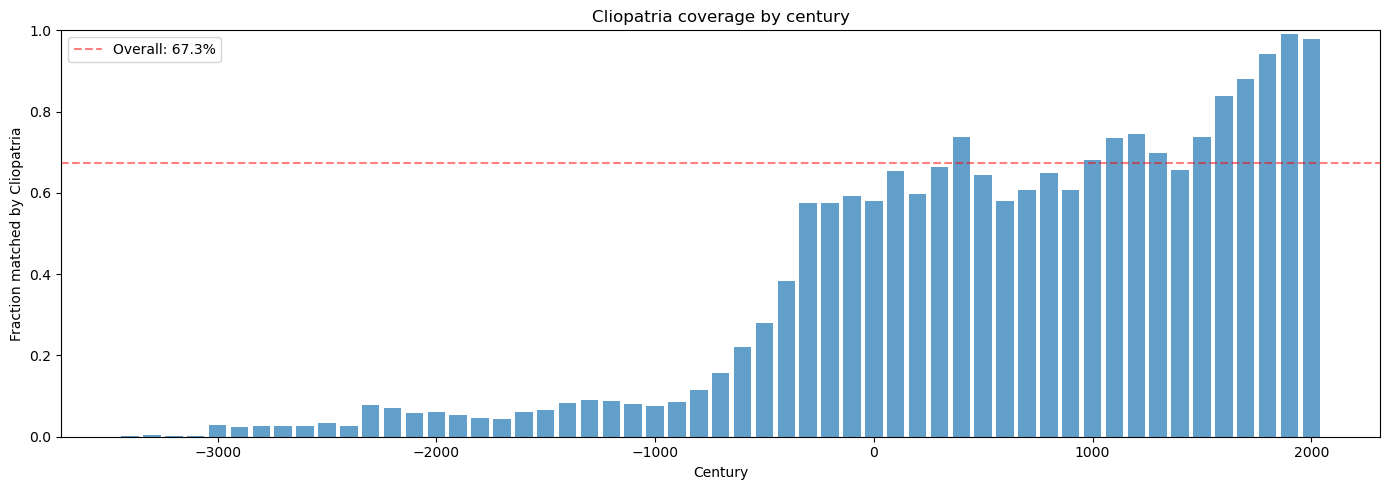

In [14]:
people_gdf_cent = people_gdf.copy()
people_gdf_cent['matched'] = people_gdf_cent['idx'].isin(matched_idx)
people_gdf_cent['century'] = (people_gdf_cent['birth_year'] // 100) * 100

by_cent = people_gdf_cent.groupby('century').agg(
    total=('matched', 'size'),
    matched=('matched', 'sum'),
).reset_index()
by_cent['frac'] = by_cent['matched'] / by_cent['total']

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(by_cent['century'], by_cent['frac'], width=80, alpha=0.7)
ax.set_xlabel('Century')
ax.set_ylabel('Fraction matched by Cliopatria')
ax.set_title('Cliopatria coverage by century')
ax.set_ylim(0, 1)
ax.axhline(y=n_matched/n_eligible, color='red', linestyle='--', alpha=0.5, label=f'Overall: {100*n_matched/n_eligible:.1f}%')
ax.legend()
plt.tight_layout()
plt.show()